#### 结合了Ridge正则化优化

假设我们有 $n $个样本，每个样本记为 $(x_i, y_i) $( $i=1,2,\ldots,n $)，为了方便表示，我们引入设计矩阵 $X $：
$$X = \begin{pmatrix}1 & x_1 & x_1^2 & \cdots & x_1^d \\1 & x_2 & x_2^2 & \cdots & x_2^d \\\vdots & \vdots & \vdots & \ddots & \vdots \\1 & x_n & x_n^2 & \cdots & x_n^d \\\end{pmatrix},$$
以及参数向量和目标向量：
$$\beta = \begin{pmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_d \end{pmatrix}, \quad
y = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{pmatrix}.$$
模型可以写作：
$$y = X\beta + \varepsilon.$$
为了估计参数 $\beta$，通常采用最小二乘法，构造目标函数（损失函数）为残差平方和：
$$J(\beta) = \sum_{i=1}^{n} \left(y_i - \hat{y}_i\right)^2 = \| y - X\beta \|^2.$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
np.random.seed(42)

X = np.sort(5 * np.random.rand(800, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(scale=0.3, size=X.shape[0]) # .ravel() 将多维数组降为一维

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# 构建多项式回归模型及优化
# 使用Pipeline将多项式特征转换和Ridge正则化组合在一起
# 通过多项式特征转换，可以捕捉数据的非线性关系；
# 通过Ridge正则化（岭回归）可以防止模型过拟合问题

# 构造pipeline：
# 第一步：PolynomialFeatures(include_bias=False)（不自动添加常数项）
# 第二步：Ridge()（岭回归）
pipeline = make_pipeline(PolynomialFeatures(include_bias=False), Ridge())

In [5]:
# 定义参数网格，用于网格搜索优化：
# - 'polynomialfeatures__degree'：多项式的阶数，范围从1到8
# - 'ridge__alpha'：岭回归中的正则化系数，值越大正则化力度越强
param_grid = {
    'polynomialfeatures__degree':[1, 2, 3, 4, 5, 6, 7, 8],
    'ridge__alpha':[0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...e', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'polynomialfeatures__degree': [1, 2, ...], 'ridge__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displa

In [6]:
print(f"Best parameters:{grid.best_params_}, Best score:{-grid.best_score_:.2f}")

Best parameters:{'polynomialfeatures__degree': 5, 'ridge__alpha': 1}, Best score:0.09


In [7]:
y_pred = grid.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE: {mse:.2f}, Test R^2: {r2:.2f}")

Test MSE: 0.10, Test R^2: 0.83


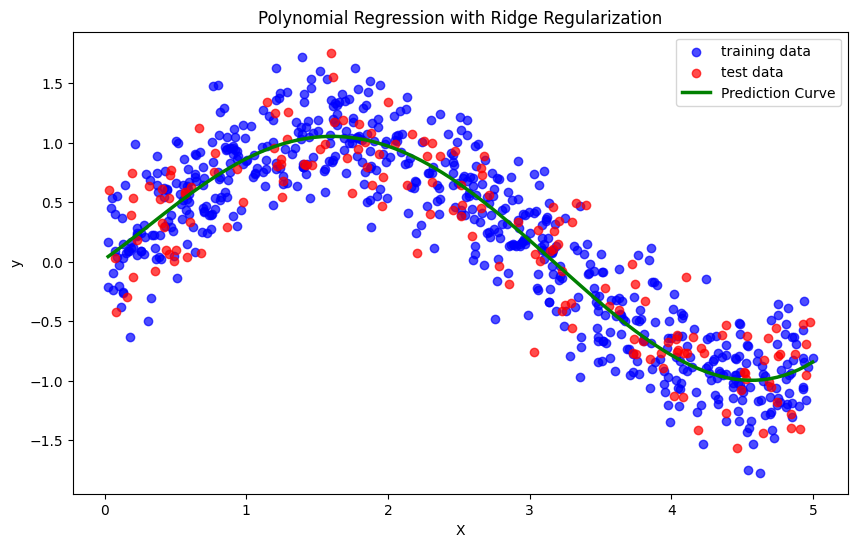

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='training Dataset', alpha=0.7)
plt.scatter(X_test, y_test, color='red', label='test Dataset', alpha=0.7)
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = grid.predict(X_plot)
plt.plot(X_plot, y_pred, color='green', linewidth=2.5, label='Prediction Curve')
plt.title("Polynomial Regression with Ridge Regularization")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

#### 当数据较少、特征维度较低，且数据呈现平滑的非线性变化时，多项式回归往往能提供较好的拟合效果，同时模型的可解释性也较强